Matriz de transição P:
[[0.7 0.3 0.  0.  0. ]
 [0.2 0.5 0.3 0.  0. ]
 [0.  0.1 0.5 0.4 0. ]
 [0.  0.  0.  0.6 0.4]
 [0.  0.  0.  0.  1. ]]

Matriz P^4:
[[0.3907 0.3294 0.1827 0.0828 0.0144]
 [0.2196 0.232  0.2076 0.216  0.1248]
 [0.0406 0.0692 0.1102 0.2936 0.4864]
 [0.     0.     0.     0.1296 0.8704]
 [0.     0.     0.     0.     1.    ]]

Probabilidade de atingir falha total exatamente no 4º ciclo: 0.0144
Em porcentagem: 1.44%

Matriz Q, estados transitórios:
[[0.7 0.3 0.  0. ]
 [0.2 0.5 0.3 0. ]
 [0.  0.1 0.5 0.4]
 [0.  0.  0.  0.6]]

Matriz R, transições para o estado absorvente:
[[0. ]
 [0. ]
 [0. ]
 [0.4]]

Matriz fundamental N:
[[6.1111 4.1667 2.5    2.5   ]
 [2.7778 4.1667 2.5    2.5   ]
 [0.5556 0.8333 2.5    2.5   ]
 [0.     0.     0.     2.5   ]]

Número médio de ciclos até absorção:
Estado inicial 0 (Funcionando): 15.2778 ciclos
Estado inicial 1 (Pequena falha): 11.9444 ciclos
Estado inicial 2 (Falhando): 6.3889 ciclos
Estado inicial 3 (Crítico): 2.5000 ciclos

Probabilida

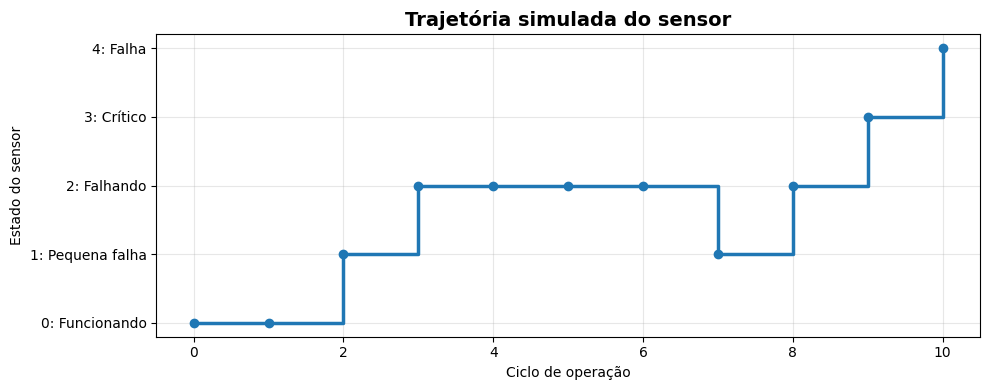

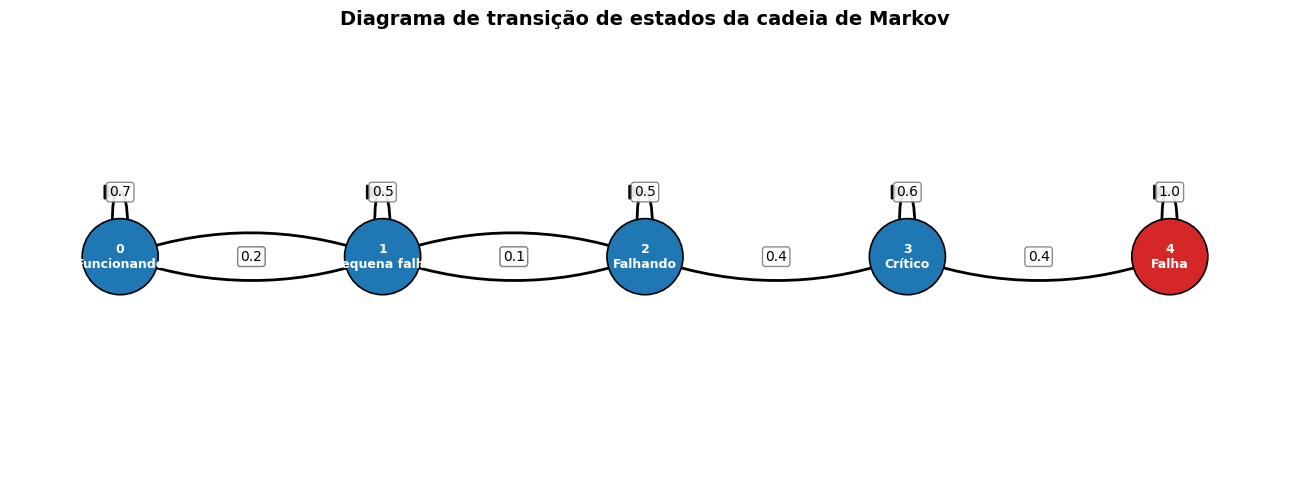


Distribuição de probabilidades após 30 ciclos:
Estado 0 (Funcionando): 0.0181
Estado 1 (Pequena falha): 0.0173
Estado 2 (Falhando): 0.0133
Estado 3 (Crítico): 0.0183
Estado 4 (Falha): 0.9330


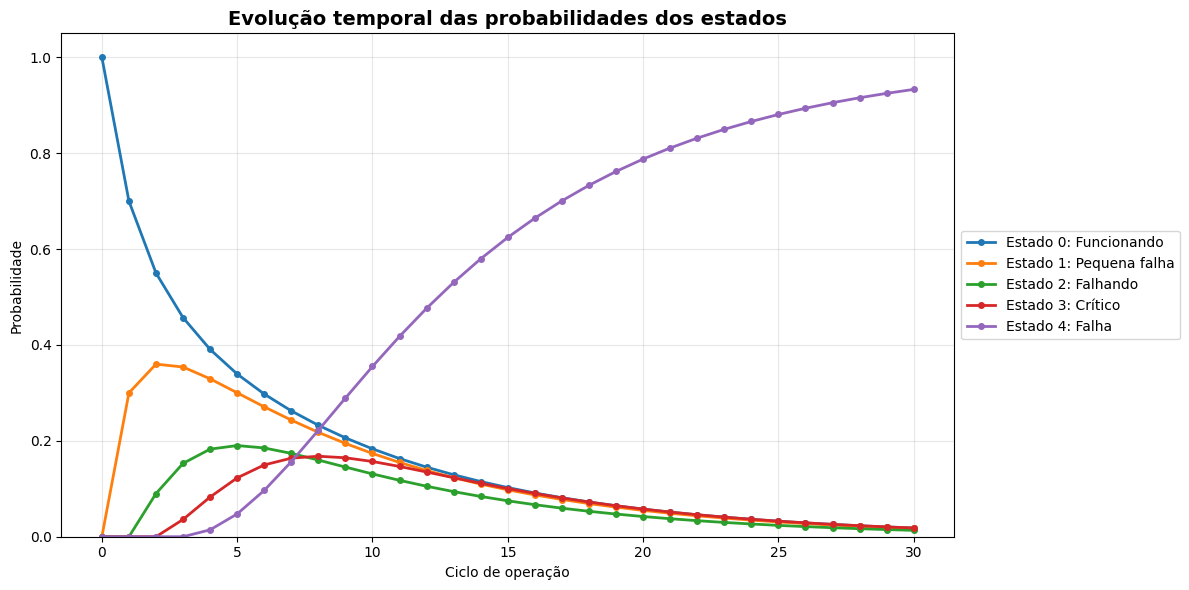

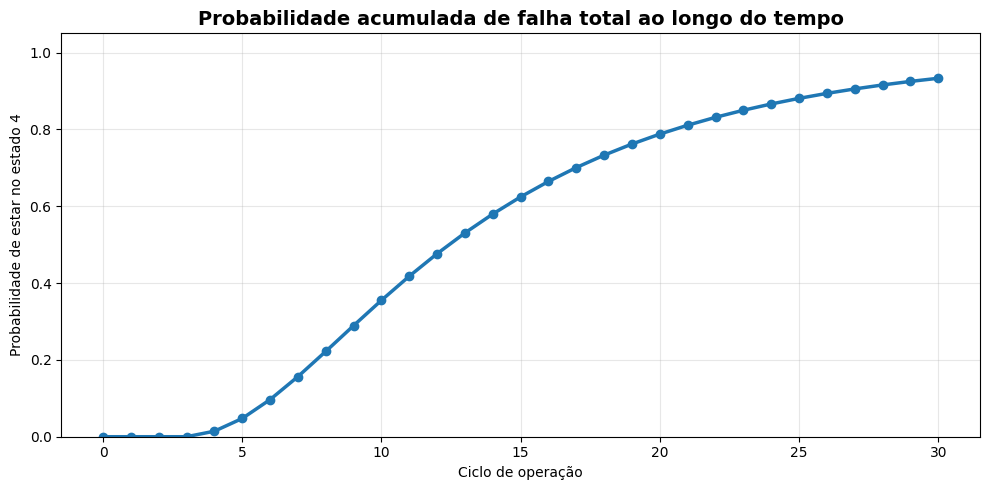

In [ ]:
# ============================================================
# Cadeia de Markov absorvente aplicada a estados de um sensor IoT
# ============================================================
#
# Estados:
# 0: Sensor totalmente operacional
# 1: Sensor com pequena degradação
# 2: Sensor com falha moderada
# 3: Sensor em modo crítico
# 4: Sensor queimado, estado absorvente
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


# ============================================================
# 1. Definição dos estados
# ============================================================

nomes_estados = {
    0: "Funcionando",
    1: "Pequena falha",
    2: "Falhando",
    3: "Crítico",
    4: "Falha"
}

estado_inicial = 0
estado_absorvente = 4


# ============================================================
# 2. Matriz de transição da cadeia de Markov
# ============================================================
#
# A linha representa o estado atual.
# A coluna representa o próximo estado.
#
# Exemplo:
# matriz_transicao[0, 1] = 0.3
# significa que, estando no estado 0, a probabilidade
# de ir para o estado 1 no próximo ciclo é 0.3.
# ============================================================

matriz_transicao = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],
    [0.2, 0.5, 0.3, 0.0, 0.0],
    [0.0, 0.1, 0.5, 0.4, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])


# ============================================================
# 3. Impressão da matriz de transição
# ============================================================

print("Matriz de transição P:")
print(matriz_transicao)


# ============================================================
# 4. Probabilidade de atingir falha total exatamente no 4º ciclo
# ============================================================
#
# Como o sensor inicia no estado 0, queremos:
#
# P(X_4 = 4 | X_0 = 0)
#
# Isso corresponde ao elemento [0, 4] da matriz P^4.
# ============================================================

numero_ciclos = 4

matriz_transicao_4_ciclos = np.linalg.matrix_power(
    matriz_transicao,
    numero_ciclos
)

probabilidade_falha_4_ciclo = matriz_transicao_4_ciclos[
    estado_inicial,
    estado_absorvente
]

print("\nMatriz P^4:")
print(matriz_transicao_4_ciclos)

print(
    f"\nProbabilidade de atingir falha total exatamente no 4º ciclo: "
    f"{probabilidade_falha_4_ciclo:.4f}"
)

print(
    f"Em porcentagem: "
    f"{probabilidade_falha_4_ciclo * 100:.2f}%"
)


# ============================================================
# 5. Separação da matriz em Q e R
# ============================================================
#
# Para cadeias absorventes:
#
# P = [ Q  R ]
#     [ 0  I ]
#
# Q: transições entre estados transitórios
# R: transições dos estados transitórios para estados absorventes
#
# Estados transitórios: 0, 1, 2, 3
# Estado absorvente: 4
# ============================================================

matriz_Q = matriz_transicao[:4, :4]
matriz_R = matriz_transicao[:4, 4:]

print("\nMatriz Q, estados transitórios:")
print(matriz_Q)

print("\nMatriz R, transições para o estado absorvente:")
print(matriz_R)


# ============================================================
# 6. Matriz fundamental da cadeia
# ============================================================
#
# A matriz fundamental é:
#
# N = (I - Q)^(-1)
#
# Cada elemento N[i, j] representa o número esperado de visitas
# ao estado j antes da absorção, dado que a cadeia começou no estado i.
# ============================================================

matriz_identidade = np.eye(matriz_Q.shape[0])

matriz_fundamental = np.linalg.inv(matriz_identidade - matriz_Q)

print("\nMatriz fundamental N:")
print(np.round(matriz_fundamental, 4))


# ============================================================
# 7. Número médio de ciclos até absorção
# ============================================================
#
# O vetor t é calculado por:
#
# t = N * 1
#
# Ou seja, soma-se cada linha da matriz fundamental.
# ============================================================

vetor_uns = np.ones((matriz_Q.shape[0], 1))

tempo_medio_absorcao = matriz_fundamental @ vetor_uns

print("\nNúmero médio de ciclos até absorção:")
for estado, tempo in enumerate(tempo_medio_absorcao.flatten()):
    print(
        f"Estado inicial {estado} "
        f"({nomes_estados[estado]}): "
        f"{tempo:.4f} ciclos"
    )


# ============================================================
# 8. Probabilidade de absorção no estado de falha total
# ============================================================
#
# A matriz de probabilidades de absorção é:
#
# B = N * R
#
# Como existe apenas um estado absorvente, B terá uma coluna.
# ============================================================

probabilidades_absorcao = matriz_fundamental @ matriz_R

print("\nProbabilidade de absorção no estado 4:")
for estado, probabilidade in enumerate(probabilidades_absorcao.flatten()):
    print(
        f"Estado inicial {estado} "
        f"({nomes_estados[estado]}): "
        f"{probabilidade:.4f}"
    )


# ============================================================
# 9. Simulação de uma trajetória da cadeia de Markov
# ============================================================
#
# A função abaixo simula a evolução do sensor ciclo a ciclo.
# A simulação termina quando o sensor chega ao estado absorvente
# ou quando atinge o número máximo de ciclos.
# ============================================================

def simular_cadeia_markov(
    matriz_transicao,
    estado_inicial=0,
    estado_absorvente=4,
    maximo_ciclos=100,
    semente=42
):
    """
    Simula uma trajetória da cadeia de Markov.

    Parâmetros:
    matriz_transicao: matriz P da cadeia
    estado_inicial: estado de partida
    estado_absorvente: estado final absorvente
    maximo_ciclos: limite máximo de ciclos simulados
    semente: valor usado para reprodutibilidade

    Retorna:
    lista com a sequência de estados visitados
    """

    np.random.seed(semente)

    estado_atual = estado_inicial
    trajetoria = [estado_atual]

    for ciclo in range(maximo_ciclos):
        estado_proximo = np.random.choice(
            a=len(matriz_transicao),
            p=matriz_transicao[estado_atual]
        )

        trajetoria.append(estado_proximo)
        estado_atual = estado_proximo

        if estado_atual == estado_absorvente:
            break

    return trajetoria


trajetoria_simulada = simular_cadeia_markov(
    matriz_transicao=matriz_transicao,
    estado_inicial=estado_inicial,
    estado_absorvente=estado_absorvente
)

print("\nTrajetória simulada:")
print(trajetoria_simulada)


# ============================================================
# 10. Gráfico da trajetória simulada
# ============================================================

plt.figure(figsize=(10, 4))

plt.step(
    range(len(trajetoria_simulada)),
    trajetoria_simulada,
    where="post",
    linewidth=2.5,
    marker="o"
)

plt.title("Trajetória simulada do sensor", fontsize=14, fontweight="bold")
plt.xlabel("Ciclo de operação")
plt.ylabel("Estado do sensor")
plt.yticks(
    ticks=list(nomes_estados.keys()),
    labels=[f"{k}: {v}" for k, v in nomes_estados.items()]
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Plot do grafo de transições
# ============================================================
#
# Cada nó representa um estado.
# Cada seta representa uma transição possível.
# O peso da seta é a probabilidade de transição.
# ============================================================

grafo_transicoes = nx.DiGraph()

# Adiciona os nós ao grafo
for estado, nome in nomes_estados.items():
    grafo_transicoes.add_node(estado, label=f"{estado}\n{nome}")

# Adiciona as arestas com probabilidades maiores que zero
for estado_origem in range(matriz_transicao.shape[0]):
    for estado_destino in range(matriz_transicao.shape[1]):
        probabilidade = matriz_transicao[estado_origem, estado_destino]

        if probabilidade > 0:
            grafo_transicoes.add_edge(
                estado_origem,
                estado_destino,
                weight=probabilidade
            )

# Posição manual para melhorar a leitura
posicoes_nos = {
    0: (0, 0),
    1: (2, 0),
    2: (4, 0),
    3: (6, 0),
    4: (8, 0)
}

plt.figure(figsize=(13, 5))

# Cores diferentes para estados transitórios e absorvente
cores_nos = [
    "#1f77b4" if estado != estado_absorvente else "#d62728"
    for estado in grafo_transicoes.nodes()
]

rotulos_nos = {
    estado: f"{estado}\n{nomes_estados[estado]}"
    for estado in grafo_transicoes.nodes()
}

nx.draw_networkx_nodes(
    grafo_transicoes,
    posicoes_nos,
    node_size=3000,
    node_color=cores_nos,
    edgecolors="black",
    linewidths=1.2
)

nx.draw_networkx_labels(
    grafo_transicoes,
    posicoes_nos,
    labels=rotulos_nos,
    font_size=9,
    font_color="white",
    font_weight="bold"
)

nx.draw_networkx_edges(
    grafo_transicoes,
    posicoes_nos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=22,
    width=2,
    connectionstyle="arc3,rad=0.18"
)

rotulos_arestas = {
    (origem, destino): f"{dados['weight']:.1f}"
    for origem, destino, dados in grafo_transicoes.edges(data=True)
}

nx.draw_networkx_edge_labels(
    grafo_transicoes,
    posicoes_nos,
    edge_labels=rotulos_arestas,
    font_size=10,
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.title(
    "Diagrama de transição de estados da cadeia de Markov",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()


# ============================================================
# 12. Evolução temporal das probabilidades dos estados
# ============================================================
#
# A distribuição inicial é:
#
# pi_0 = [1, 0, 0, 0, 0]
#
# Isso significa que o sensor inicia com 100% de probabilidade
# no estado 0.
#
# A cada ciclo:
#
# pi_{k+1} = pi_k * P
# ============================================================

quantidade_ciclos = 30

distribuicao_inicial = np.array([1, 0, 0, 0, 0])

distribuicoes_temporais = [distribuicao_inicial]

for ciclo in range(1, quantidade_ciclos + 1):
    nova_distribuicao = distribuicoes_temporais[-1] @ matriz_transicao
    distribuicoes_temporais.append(nova_distribuicao)

distribuicoes_temporais = np.array(distribuicoes_temporais)

print("\nDistribuição de probabilidades após 30 ciclos:")
for estado in range(5):
    print(
        f"Estado {estado} ({nomes_estados[estado]}): "
        f"{distribuicoes_temporais[-1, estado]:.4f}"
    )


# ============================================================
# 13. Gráfico da evolução temporal
# ============================================================

plt.figure(figsize=(12, 6))

for estado in range(5):
    plt.plot(
        range(quantidade_ciclos + 1),
        distribuicoes_temporais[:, estado],
        marker="o",
        linewidth=2,
        markersize=4,
        label=f"Estado {estado}: {nomes_estados[estado]}"
    )

plt.title(
    "Evolução temporal das probabilidades dos estados",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Ciclo de operação")
plt.ylabel("Probabilidade")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


# ============================================================
# 14. Gráfico específico da probabilidade de falha total
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(quantidade_ciclos + 1),
    distribuicoes_temporais[:, estado_absorvente],
    marker="o",
    linewidth=2.5
)

plt.title(
    "Probabilidade acumulada de falha total ao longo do tempo",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Ciclo de operação")
plt.ylabel("Probabilidade de estar no estado 4")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()